In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
from matplotlib.patches import Patch

os.environ["CUDA_VISIBLE_DEVICES"]= "7"

import analysis_utils as base

set_size = base.set_size
pgf_with_latex = base.pgf_with_latex
doc_width_pt = base.doc_width_pt

plt.rcParams.update(pgf_with_latex)

sns.set_palette("colorblind")


## Compute time vs. instance hardness (SlidingTilePuzzle, 8-puzzle)

Sliding-puzzle counterpart to `analysis-compute_time-hardness.ipynb` (Lights Out) -
same question (does a harder instance get more pondering?), same overall pipeline
(load a trained checkpoint, roll out episodes, solve each instance exactly, check
the compute-time/hardness correlation), adapted for `jumanji`'s
`SlidingTilePuzzle-v0` (CNN+Transformer implicit-CoT actor, adaptive compute
budget). Hyperparameter defaults below match a well-trained (100% eval solve
rate) run from
[`slidingpuzzle-icot_sweep_2`](https://wandb.ai/bpychan-university-of-alberta/slidingpuzzle-icot_sweep_2)
(run `xx265e7u`, `mn1-mx5` group - adaptive budget 1-5, seed 8).

Three differences from the Lights Out notebook, all consequences of how
`SlidingTilePuzzle` differs from `LightsOutEnv`:

- **The goal is fixed**, not sampled per episode: every episode's target is the
  same canonical solved arrangement (`1..N**2-1` in row-major order, blank
  last). So there's no `goal_grid` to track per episode - "hardness" is purely
  a property of the *initial* (or, per-step, *current*) puzzle.
- **Exact shortest path is BFS, not GF(2)**: Lights Out's shortest path is a
  linear-algebra problem (`gf2_min_weight_solution`); the sliding puzzle's is a
  shortest-path problem over the puzzle's state graph (swap the blank with an
  orthogonal neighbor). For the 8-puzzle (`GRID_SIZE=3`, 181440 reachable
  states) a single BFS from the solved state gives the *exact* optimal
  distance-to-goal for every reachable state at once - see
  `sliding_puzzle_prepare`/`sliding_puzzle_shortest_path` below, the direct
  analogue of `gf2_prepare`/`gf2_min_weight_solution`. This does **not** scale
  to the 15-puzzle (`GRID_SIZE=4`, ~10^13 states) - that would need a
  per-instance heuristic search (e.g. IDA* with the Manhattan-distance
  heuristic) instead - see that function's docstring.
- **CNN+Transformer, not plain Transformer**: `SlidingTilePuzzle`'s native
  `(GRID_SIZE, GRID_SIZE)` observation is kept spatial (via
  `stoix.wrappers.grid_observation.GridObservationWrapper`, not flattened) for
  a CNN `input_layer` ahead of the Chain-of-Thought transformer torso - see
  `network=cnn_transformer_compute` below.

**Before running:** fill in `CHECKPOINT_REL_DIR`/`CHECKPOINT_UID` once a
trained checkpoint is available locally - none is saved on this machine
(`save_model` was off for every run in the wandb sweep above; those runs were
launched on a different cluster machine - see
`ramdp_experiments/slurm/slidingpuzzle-icot.sh`). The network hyperparameters
(`HIDDEN_DIM`, `NUM_LAYERS`, ...) must exactly match the checkpoint's training
run, or `Checkpointer.restore_params` will fail on a param-shape mismatch.
Set `USE_RANDOM_POLICY=True` to smoke-test the pipeline without one.

In [2]:
import copy
import os
import sys
from pathlib import Path

# Hydra's `hydra.searchpath` for stoix's configs (`file://stoix/configs`) is
# relative to cwd, so run everything from the repo root - matching how
# jumanji_sweep.py/ff_ppo.py are always invoked.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "ramdp_experiments" else Path.cwd()
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import collections

import flax.linen as nn
import hydra
import jax
import jax.numpy as jnp
import jumanji
import numpy as np
import pandas as pd
from hydra import compose, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra
from stoa.env_adapters.jumanji import JumanjiToStoa
from stoa.utility_wrappers.obs_extract import ObservationExtractWrapper

from stoix.base_types import ActorCriticParams
from stoix.networks.base import FeedForwardCritic
from stoix.networks.base_compute import FeedForwardActorWithComputeTime as Actor
from stoix.systems.ramdp_vpg.ff_reinforce import get_distribution_act_fn_with_compute_time
from stoix.utils import make_env as environments
from stoix.utils.checkpointing import Checkpointer


In [3]:
# --- Checkpoint - fill in once a trained SlidingTilePuzzle checkpoint is
# available locally. These three map directly onto
# config.logger.checkpointing.load_args (rel_dir, checkpoint_uid) and
# model_name=config.system.system_name, i.e. exactly the knobs
# `learner_setup` itself uses to restore a checkpoint - see
# stoix/utils/checkpointing.py.
CHECKPOINT_REL_DIR = "/home/bryanpu1/projects/iclr_2027/Stoix/ramdp_experiments/checkpoints"  # e.g. "/path/to/run_dir/checkpoints" (absolute path is fine)
CHECKPOINT_UID = "20260923063537"  # e.g. "20260101120000"
CHECKPOINT_MODEL_NAME = "ramdp_ff_ppo"  # config.system.system_name default for ff_ppo.py

# Skips the checkpoint restore entirely and rolls out the freshly-initialized
# (untrained) actor instead - lets the rest of the pipeline (env, BFS solver,
# rollout loop, analysis/plots) be smoke-tested without a trained checkpoint. A
# random policy has no reason to spend more compute on harder instances, so
# expect ~0 correlation - this only tests that the code runs end-to-end, not
# that the trained agent behaves sensibly. It also essentially never solves an
# 8-puzzle scrambled by NUM_RANDOM_MOVES random moves within the time limit,
# so expect solved=False almost everywhere.
USE_RANDOM_POLICY = False

# --- Env: jumanji's SlidingTilePuzzle-v0 (8-puzzle) ---
GRID_SIZE = 3  # 3 = 8-puzzle. sliding_puzzle_prepare's BFS only scales to this - see its docstring.
NUM_RANDOM_MOVES = 200  # RandomWalkGenerator's scramble depth - analogous to Lights Out's `dist`.
TIME_LIMIT = 80  # env.kwargs.time_limit - matches training.
EVAL_TIME_LIMIT = 80  # env.eval_kwargs.time_limit - a longer budget for the eval env.
# SlidingTilePuzzle's generator is train/eval-symmetric (unlike LightsOutEnv,
# whose eval env samples harder goals) - the *only* difference between
# environments.make()'s `env`/`eval_env` here is TIME_LIMIT vs
# EVAL_TIME_LIMIT. Flip to True to roll out with the longer eval time limit.
USE_EVAL_ENV = False

# --- Network: CNN+Transformer implicit-CoT, adaptive compute budget. Must
# exactly match the checkpoint's training run (see the intro markdown cell).
# Defaults below match wandb run `xx265e7u` in slidingpuzzle-icot_sweep_2
# (mn1-mx5 group, 100% eval solve rate).
HIDDEN_DIM = 16
NUM_LAYERS = 2
NUM_HEADS = 16
MLP_DIM = 256
QKV_DIM = 256
MIN_STEPS = 1
MAX_STEPS = 5
HALTING_TEMPERATURE = 1.0
USE_INPUT_LAYER_NORM = True
USE_SANDWICH_NORM = False
USE_RMSNORM = True
STOP_GRADIENT_HALTING_INPUT = True
QAC_VARIANT = "reinforce"  # must match qac_variant used to train the checkpoint

# CNN input_layer (actor and critic share these) - stoix.networks.torso.CNNTorso.
CNN_CHANNEL_SIZES = (8, 8)
CNN_KERNEL_SIZES = (2, 1)
CNN_STRIDES = (1,)
CNN_HIDDEN_SIZES = (64,)
CRITIC_LAYER_SIZES = (64, 64)  # critic's post-CNN MLPTorso

# --- Rollout ---
NUM_EVAL_EPISODES = 50000
SEED = 0
EVALUATION_GREEDY = True  # match training-time stochastic policy; True evaluates the mode action instead
# rollout_episodes re-JITs and re-runs NUM_EVAL_EPISODES full episodes every time the
# rollout cell executes, which is slow - once a rollout has run, its dataframe is
# cached to ROLLOUT_CACHE_PATH (see below) and reloaded from there on subsequent runs
# instead of being recomputed. Set True to ignore any cache and force a fresh rollout
# (e.g. after changing the checkpoint or network hyperparameters above without also
# changing NUM_EVAL_EPISODES/SEED, which the cache path does not otherwise capture).
FORCE_REROLLOUT = True


In [4]:
def build_stoix_config():
    """Composes the same DictConfig ff_ppo.py's @hydra.main would build for a
    SlidingTilePuzzle / cnn_transformer_compute run, via the CLI overrides
    ramdp_experiments/jumanji_sweep.py's Job.command() would emit for this
    (system=ff_ppo_reinforce, architecture=cnn+transformer, env=slidingtile)
    combo."""
    overrides = [
        # jumanji/slidingtile_grid.yaml keeps the native (GRID_SIZE, GRID_SIZE)
        # spatial observation (vs. jumanji/slidingtile.yaml's flattened one)
        # for the CNN input_layer - see cnn_transformer_compute.yaml.
        "env=jumanji/slidingtile_grid",
        f"env.kwargs.generator.grid_size={GRID_SIZE}",
        f"env.kwargs.generator.num_random_moves={NUM_RANDOM_MOVES}",
        f"env.kwargs.time_limit={TIME_LIMIT}",
        f"+env.eval_kwargs.time_limit={EVAL_TIME_LIMIT}",
        "network=cnn_transformer_compute",
        f"network.actor_network.pre_torso.hidden_dim={HIDDEN_DIM}",
        f"++network.actor_network.pre_torso.num_layers={NUM_LAYERS}",
        f"++network.actor_network.pre_torso.num_heads={NUM_HEADS}",
        f"++network.actor_network.pre_torso.mlp_dim={MLP_DIM}",
        f"++network.actor_network.pre_torso.qkv_dim={QKV_DIM}",
        f"network.actor_network.pre_torso.min_steps={MIN_STEPS}",
        f"network.actor_network.pre_torso.max_steps={MAX_STEPS}",
        f"network.actor_network.pre_torso.halting_temperature={HALTING_TEMPERATURE}",
        f"++network.actor_network.pre_torso.use_input_layer_norm={USE_INPUT_LAYER_NORM}",
        f"++network.actor_network.pre_torso.use_sandwich_norm={USE_SANDWICH_NORM}",
        f"++network.actor_network.pre_torso.use_rmsnorm={USE_RMSNORM}",
        "++network.actor_network.pre_torso.stop_gradient_halting_input="
        f"{STOP_GRADIENT_HALTING_INPUT}",
        f"network.actor_network.input_layer.channel_sizes=[{','.join(map(str, CNN_CHANNEL_SIZES))}]",
        f"network.actor_network.input_layer.kernel_sizes=[{','.join(map(str, CNN_KERNEL_SIZES))}]",
        f"network.actor_network.input_layer.strides=[{','.join(map(str, CNN_STRIDES))}]",
        f"network.actor_network.input_layer.hidden_sizes=[{','.join(map(str, CNN_HIDDEN_SIZES))}]",
        f"network.critic_network.input_layer.channel_sizes=[{','.join(map(str, CNN_CHANNEL_SIZES))}]",
        f"network.critic_network.input_layer.kernel_sizes=[{','.join(map(str, CNN_KERNEL_SIZES))}]",
        f"network.critic_network.input_layer.strides=[{','.join(map(str, CNN_STRIDES))}]",
        f"network.critic_network.input_layer.hidden_sizes=[{','.join(map(str, CNN_HIDDEN_SIZES))}]",
        f"network.critic_network.pre_torso.layer_sizes=[{','.join(map(str, CRITIC_LAYER_SIZES))}]",
        f"system.qac_variant={QAC_VARIANT}",
        f"arch.evaluation_greedy={EVALUATION_GREEDY}",
    ]
    GlobalHydra.instance().clear()
    with initialize_config_dir(
        config_dir=str(REPO_ROOT / "stoix/configs/default/anakin"), version_base=None
    ):
        config = compose(config_name="default_ramdp_ff_ppo.yaml", overrides=overrides)
    return config


config = build_stoix_config()


In [5]:
def build_actor_and_restore(config, seed=0):
    """Mirrors the actor/critic construction in
    stoix.systems.ramdp_vpg.ff_ppo.learner_setup (skipping the
    optimizer/learner_fn machinery, which pure inference doesn't need), then
    either restores the actor's trained params from CHECKPOINT_REL_DIR/UID or,
    if USE_RANDOM_POLICY, returns the freshly-initialized params as-is. Returns
    (env, eval_env, act_fn, actor_params, actor_network) - actor_network is
    returned (not just act_fn) so the t-SNE section further down can run just
    its CNN input_layer on a puzzle, without going through the full
    torso/action_head. `env` is `environments.make()`'s vmapped/auto-reset
    training env (used below only for its action_space) - it is NOT suitable
    for the single-episode rollout loop, see build_puzzle_env."""
    assert USE_RANDOM_POLICY or CHECKPOINT_UID is not None, (
        "Fill in CHECKPOINT_REL_DIR/CHECKPOINT_UID in the config cell before running this "
        "(or set USE_RANDOM_POLICY=True to smoke-test the pipeline without one)."
    )

    env, eval_env = environments.make(config=config)
    num_actions = int(env.action_space().num_values)

    key = jax.random.PRNGKey(seed)
    actor_net_key, critic_net_key = jax.random.split(key)

    actor_input_layer = hydra.utils.instantiate(config.network.actor_network.input_layer)
    actor_torso = hydra.utils.instantiate(config.network.actor_network.pre_torso)
    actor_action_head = hydra.utils.instantiate(
        config.network.actor_network.action_head, action_dim=num_actions
    )
    actor_network = Actor(
        input_layer=actor_input_layer, torso=actor_torso, action_head=actor_action_head
    )

    init_x = eval_env.observation_space().generate_value()
    init_x = jax.tree_util.tree_map(lambda x: x[None, ...], init_x)
    actor_params = actor_network.init(actor_net_key, init_x, torso_kwargs={"rng": actor_net_key})

    if not USE_RANDOM_POLICY:
        # QAC_VARIANT="reinforce" -> plain V-only critic (FeedForwardCritic), matching
        # ff_ppo.py's learner_setup. The critic is only needed to reconstruct the
        # checkpoint's full ActorCriticParams structure for Checkpointer.restore_params -
        # its params are discarded below, since rollouts here only use the actor.
        critic_input_layer = hydra.utils.instantiate(config.network.critic_network.input_layer)
        critic_torso = hydra.utils.instantiate(config.network.critic_network.pre_torso)
        critic_head = hydra.utils.instantiate(config.network.critic_network.critic_head)
        critic_network = FeedForwardCritic(
            input_layer=critic_input_layer, torso=critic_torso, critic_head=critic_head
        )
        critic_params = critic_network.init(critic_net_key, init_x)
        params = ActorCriticParams(actor_params, critic_params)

        loaded_checkpoint = Checkpointer(
            model_name=CHECKPOINT_MODEL_NAME,
            rel_dir=CHECKPOINT_REL_DIR or "checkpoints",
            checkpoint_uid=CHECKPOINT_UID,
        )
        restored_params, _ = loaded_checkpoint.restore_params(input_params=params)
        actor_params = restored_params.actor_params

    act_fn = get_distribution_act_fn_with_compute_time(config, actor_network.apply)
    return env, eval_env, act_fn, actor_params, actor_network


def build_puzzle_env(config):
    """A single, un-batched, TRAIN-time-limit SlidingTilePuzzle env - the
    un-batched counterpart to `environments.make()`'s `env`.

    `environments.make()`'s `env` (see `stoix.utils.make_env.make_jumanji_env`)
    is wrapped with AddRNGKey/AutoResetWrapper/VmapWrapper (`apply_core_wrappers`)
    for the vectorized training loop, so it expects a *batched* PRNG key on
    reset - unlike `eval_env`, which make_jumanji_env deliberately leaves
    un-wrapped for single-episode evaluation. rollout_episodes below needs an
    un-batched env for the train time_limit too, so this rebuilds it the same
    way make_jumanji_env builds `eval_env` (JumanjiToStoa +
    ObservationExtractWrapper('puzzle') + GridObservationWrapper) but with
    TIME_LIMIT instead of EVAL_TIME_LIMIT, skipping apply_core_wrappers
    entirely. SlidingTilePuzzle's generator is train/eval-symmetric (unlike
    LightsOutEnv's harder eval goals), so this differs from eval_env only in
    time_limit."""
    env_kwargs = dict(hydra.utils.instantiate(copy.deepcopy(config.env.kwargs)))
    puzzle_env = jumanji.make(config.env.scenario.name, **env_kwargs)
    puzzle_env = JumanjiToStoa(puzzle_env)
    puzzle_env = ObservationExtractWrapper(puzzle_env, config.env.observation_attribute)
    puzzle_env, _ = environments.apply_optional_wrappers((puzzle_env, puzzle_env), config)
    return puzzle_env


env, eval_env, act_fn, actor_params, actor_network = build_actor_and_restore(config, seed=SEED)
rollout_env = eval_env if USE_EVAL_ENV else build_puzzle_env(config)

Created environments for Suite: jumanji - Scenario: SlidingTilePuzzle-v0


### Shortest path to the solved puzzle (BFS)

Sliding the blank tile toggles which permutation the puzzle is in; the shortest
path from any reachable state to the solved arrangement is a standard
shortest-path problem on that permutation graph (edges = swap the blank with
an orthogonal neighbor). Since the goal is fixed (unlike Lights Out's
per-episode goal), a single breadth-first search *from* the solved state gives
the exact optimal distance *to* the solved state for every reachable state at
once - `sliding_puzzle_prepare` does this once (181440 reachable states for
the 8-puzzle, `GRID_SIZE=3` - exactly half of 3x3's 9! permutations, the other
half being unreachable by an even number of tile swaps);
`sliding_puzzle_shortest_path` then does an O(1) dict lookup per instance.
This does not scale to the 15-puzzle (`GRID_SIZE=4`) - see
`sliding_puzzle_prepare`'s docstring.

In [6]:
def make_solved_puzzle(grid_size):
    """The fixed goal arrangement every SlidingTilePuzzle episode shares:
    1..grid_size**2-1 in row-major order, with the blank (0) last - matches
    jumanji.environments.logic.sliding_tile_puzzle.generator.Generator.make_solved_puzzle."""
    tiles = np.arange(1, grid_size * grid_size + 1)
    tiles[-1] = 0
    return tiles.reshape(grid_size, grid_size)


def sliding_puzzle_prepare(grid_size, max_states=500_000):
    """Breadth-first search from the solved puzzle over the sliding-puzzle
    move graph (swap the blank with an orthogonal neighbor), giving the exact
    optimal distance-to-goal for every reachable state in one pass - the
    sliding-tile analogue of gf2_prepare (prepare once, solve many). Raises if
    the reachable state space is too large to search exhaustively - expected
    to hold for grid_size=3 (181440 reachable states, half of 9! due to the
    puzzle's parity constraint) but not grid_size>=4 (grid_size=4's 15-puzzle
    has ~10^13 reachable states - that would need a per-instance heuristic
    search, e.g. IDA* with the Manhattan-distance heuristic, instead)."""
    solved = tuple(make_solved_puzzle(grid_size).flatten())
    dist = {solved: 0}
    queue = collections.deque([solved])
    while queue:
        state = queue.popleft()
        next_dist = dist[state] + 1
        grid = np.array(state).reshape(grid_size, grid_size)
        blank_r, blank_c = divmod(state.index(0), grid_size)
        for dr, dc in ((-1, 0), (1, 0), (0, -1), (0, 1)):
            new_r, new_c = blank_r + dr, blank_c + dc
            if 0 <= new_r < grid_size and 0 <= new_c < grid_size:
                new_grid = grid.copy()
                new_grid[blank_r, blank_c], new_grid[new_r, new_c] = (
                    new_grid[new_r, new_c],
                    new_grid[blank_r, blank_c],
                )
                new_state = tuple(new_grid.flatten())
                if new_state not in dist:
                    dist[new_state] = next_dist
                    queue.append(new_state)
                    assert len(dist) <= max_states, (
                        f"reachable state space exceeded {max_states} states - too large to "
                        "brute-force distances over (see this function's docstring)."
                    )
    return dist


def sliding_puzzle_shortest_path(prepared, puzzle):
    """Exact shortest-path length from `puzzle` (an (N, N) array) to the
    solved arrangement, or None if unreachable (shouldn't happen for states
    produced by RandomWalkGenerator, which only ever scrambles *from* the
    solved state - kept for parity with gf2_min_weight_solution's
    infeasibility handling)."""
    return prepared.get(tuple(np.asarray(puzzle).flatten().astype(int)))


SOLVED_PUZZLE = make_solved_puzzle(GRID_SIZE)
puzzle_dist_prepared = sliding_puzzle_prepare(GRID_SIZE)
print(
    f"{len(puzzle_dist_prepared)} reachable states, "
    f"max shortest-path length {max(puzzle_dist_prepared.values())}, "
    f"min shortest-path length {min(puzzle_dist_prepared.values())}"
)


181440 reachable states, max shortest-path length 31, min shortest-path length 0


In [7]:
def rollout_episodes(env, act_fn, params, num_episodes, seed, max_steps):
    """Runs `num_episodes` episodes against `env` (a single, un-batched env -
    `eval_env`/build_puzzle_env(config)'s env; never environments.make()'s
    vmapped/auto-reset `env`, which expects a batched PRNG key), recording
    each episode's initial puzzle, the actor's mean compute time per action,
    and - for the per-step hardness-vs-compute-time analysis further down -
    every step's own puzzle (`states`), chosen action (`actions`), and compute
    time (`compute_times`). There is no per-episode goal to record:
    SlidingTilePuzzle's goal (SOLVED_PUZZLE) is the same for every episode.

    Vectorized: `rollout_one_episode` runs a single episode via `jax.lax.scan`
    over a fixed `max_steps` (pass the env's time_limit - every episode
    truncates by then), freezing the env state and flagging `valid=False` once
    `timestep.last()` fires so steps taken after termination don't corrupt the
    trajectory or get counted; `jax.vmap`+`jax.jit` then run all `num_episodes`
    of those in one compiled call - see analysis-compute_time-hardness.ipynb's
    (Lights Out) rollout_episodes for the full rationale, identical here."""

    def rollout_one_episode(params, key):
        reset_key, key = jax.random.split(key)
        env_state, timestep = env.reset(reset_key)
        initial_puzzle = env_state.puzzle

        def step_fn(carry, _):
            key, env_state, timestep, already_done = carry
            current_puzzle = env_state.puzzle
            valid = jnp.logical_not(already_done)

            key, act_key = jax.random.split(key)
            obs = jax.tree_util.tree_map(
                lambda x: x[jnp.newaxis, ...], timestep.observation
            )
            action, compute_time, _, _ = act_fn(params, obs, act_key)
            stepped_env_state, stepped_timestep = env.step(env_state, action.squeeze(0))

            # Freeze the env once done, so scan iterations past termination
            # repeat the final state instead of stepping past a terminal
            # transition (whose next-state isn't meaningful for this env).
            next_env_state = jax.tree_util.tree_map(
                lambda new, old: jnp.where(already_done, old, new), stepped_env_state, env_state
            )
            next_timestep = jax.tree_util.tree_map(
                lambda new, old: jnp.where(already_done, old, new), stepped_timestep, timestep
            )
            next_done = jnp.logical_or(already_done, stepped_timestep.last())

            step_record = {
                "puzzle": current_puzzle,
                "action": action.squeeze(),
                "compute_time": compute_time.squeeze(),
                "valid": valid,
            }
            return (key, next_env_state, next_timestep, next_done), step_record

        init_carry = (key, env_state, timestep, jnp.array(False))
        final_carry, step_records = jax.lax.scan(
            step_fn, init_carry, xs=None, length=max_steps
        )
        _, _, final_timestep, _ = final_carry

        valid = step_records["valid"]
        step_count = jnp.sum(valid)
        return {
            "initial_puzzle": initial_puzzle,
            "states": step_records["puzzle"],
            "actions": step_records["action"],
            "compute_times": step_records["compute_time"],
            "valid_steps": valid,
            "compute_time": jnp.sum(step_records["compute_time"] * valid) / step_count,
            "episode_length": step_count,
            "solved": final_timestep.reward.squeeze() >= 1.0,
        }

    episode_keys = jax.random.split(jax.random.PRNGKey(seed), num_episodes)
    batch = jax.jit(jax.vmap(rollout_one_episode, in_axes=(None, 0)))(params, episode_keys)
    batch = jax.tree_util.tree_map(np.asarray, batch)

    return [
        {
            "episode": episode,
            "initial_puzzle": batch["initial_puzzle"][episode],
            # Per-step trajectory, padded to max_steps - use valid_steps to
            # drop the padding after the episode actually ended (see
            # build_step_dataframe below).
            "states": batch["states"][episode],
            "actions": batch["actions"][episode],
            "compute_times": batch["compute_times"][episode],
            "valid_steps": batch["valid_steps"][episode],
            "compute_time": float(batch["compute_time"][episode]),
            "episode_length": int(batch["episode_length"][episode]),
            "solved": bool(batch["solved"][episode]),
        }
        for episode in range(num_episodes)
    ]


ROLLOUT_MAX_STEPS = EVAL_TIME_LIMIT if USE_EVAL_ENV else TIME_LIMIT

# Cache path encodes the knobs that change what a rollout contains (scramble
# depth, policy identity, sample size/seed) so switching any of them naturally
# misses the cache instead of silently loading another run's dataframe - it
# does NOT cover network hyperparameters (HIDDEN_DIM, ...), so use
# FORCE_REROLLOUT after changing those without also changing
# NUM_EVAL_EPISODES/SEED. `_ROLLOUT_SCHEMA_VERSION` guards against loading a
# cache saved by an older, differently-shaped rollout_episodes (e.g. one
# predating the per-step actions field) - bump it whenever rollout_episodes's
# per-episode record changes.
_ROLLOUT_SCHEMA_VERSION = 2
_policy_tag = "random" if USE_RANDOM_POLICY else (CHECKPOINT_UID or "unknown_checkpoint")
ROLLOUT_CACHE_PATH = (
    REPO_ROOT
    / "ramdp_experiments"
    / (
        f"rollout_cache-slidingtile_gs{GRID_SIZE}-nrm{NUM_RANDOM_MOVES}-{_policy_tag}"
        f"-n{NUM_EVAL_EPISODES}-seed{SEED}-v{_ROLLOUT_SCHEMA_VERSION}.pkl"
    )
)

if ROLLOUT_CACHE_PATH.exists() and not FORCE_REROLLOUT:
    df = pd.read_pickle(ROLLOUT_CACHE_PATH)
    print(f"Loaded cached rollout dataframe ({len(df)} episodes) from {ROLLOUT_CACHE_PATH}")
else:
    records = rollout_episodes(
        rollout_env, act_fn, actor_params, NUM_EVAL_EPISODES, seed=SEED, max_steps=ROLLOUT_MAX_STEPS
    )
    for r in records:
        r["shortest_path_length"] = sliding_puzzle_shortest_path(
            puzzle_dist_prepared, r["initial_puzzle"]
        )
    df = pd.DataFrame.from_records(records)
    df.to_pickle(ROLLOUT_CACHE_PATH)
    print(f"Saved rollout dataframe ({len(df)} episodes) to {ROLLOUT_CACHE_PATH}")

# Drop episodes whose initial_puzzle was already solved (shortest_path_length
# == 0): RandomWalkGenerator's scramble occasionally wanders back to the
# solved state by chance (every move is trivially reversible - see
# sliding_puzzle_prepare's markdown above), so these are rare but real; they
# aren't meaningful "hardness" instances (there's no puzzle left to solve),
# and previously showed up as a stray shortest_path_length == 0 point on the
# episode-level plots below. Applied after the cache load/compute branch
# above (not baked into the cached dataframe itself) so it always applies
# uniformly, including to a cache saved before this filter existed.
n_zero_shortest_path = int((df["shortest_path_length"] == 0).sum())
if n_zero_shortest_path:
    print(
        f"Dropping {n_zero_shortest_path}/{len(df)} episodes with shortest_path_length == 0 "
        "(initial_puzzle was already solved)."
    )
    df = df[df["shortest_path_length"] != 0].reset_index(drop=True)

n_infeasible = df["shortest_path_length"].isna().sum()
if n_infeasible:
    print(f"{n_infeasible}/{len(df)} episodes had no feasible solution (unexpected).")
df.head()

Saved rollout dataframe (50000 episodes) to /home/bryanpu1/projects/iclr_2027/Stoix/ramdp_experiments/rollout_cache-slidingtile_gs3-nrm200-20260923063537-n50000-seed0-v2.pkl
Dropping 1/50000 episodes with shortest_path_length == 0 (initial_puzzle was already solved).


,episode,initial_puzzle,states,actions,compute_times,valid_steps,compute_time,episode_length,solved,shortest_path_length
0,0,"[[5, 4, 1], [3, 2, 8], [6, 7, 0]]","[[[5, 4, 1], [3, 2, 8], [6, 7, 0]], [[5, 4, 1]...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 2.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[True, True, True, True, True, True, True, Tru...",1.012500,80,False,20
1,1,"[[0, 2, 4], [3, 6, 1], [5, 7, 8]]","[[[0, 2, 4], [3, 6, 1], [5, 7, 8]], [[0, 2, 4]...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[True, True, True, True, True, True, True, Tru...",1.000000,80,False,22
2,2,"[[4, 5, 6], [8, 1, 7], [3, 2, 0]]","[[[4, 5, 6], [8, 1, 7], [3, 2, 0]], [[4, 5, 6]...","[3, 3, 0, 1, 1, 2, 3, 0, 0, 3, 2, 2, 1, 0, 0, ...","[1.0, 2.0, 1.0, 1.0, 5.0, 3.0, 2.0, 1.0, 1.0, ...","[True, True, True, True, True, True, True, Tru...",2.394737,38,True,22
3,3,"[[3, 2, 8], [1, 0, 5], [7, 6, 4]]","[[[3, 2, 8], [1, 0, 5], [7, 6, 4]], [[3, 2, 8]...","[1, 0, 3, 2, 1, 2, 3, 0, 1, 0, 3, 3, 2, 1, 0, ...","[1.0, 1.0, 2.0, 1.0, 5.0, 5.0, 1.0, 2.0, 1.0, ...","[True, True, True, True, True, True, True, Tru...",1.954545,22,True,20
4,4,"[[8, 3, 5], [2, 7, 4], [6, 1, 0]]","[[[8, 3, 5], [2, 7, 4], [6, 1, 0]], [[8, 3, 5]...","[0, 3, 2, 1, 0, 0, 3, 2, 3, 0, 1, 2, 1, 2, 3, ...","[1.0, 3.0, 3.0, 2.0, 1.0, 2.0, 2.0, 2.0, 1.0, ...","[True, True, True, True, True, True, True, Tru...",2.866667,30,True,24


In [8]:
# initial_puzzle holds numpy arrays, which pandas can't hash for groupby
# ("unhashable type: 'numpy.ndarray'") - converting each to a tuple first (on
# a copy, via assign - df itself is left untouched) makes it groupable, to see
# how many of the NUM_EVAL_EPISODES sampled instances are actually distinct
# rather than repeats. Unlike Lights Out there's only one grid to check here
# (the goal is fixed, so there's no (initial, goal) pair).
unique_counts = (
    df.assign(initial_puzzle=df["initial_puzzle"].apply(lambda p: tuple(p.flatten())))
    .groupby("initial_puzzle")
    .size()
    .reset_index(name="count")
)
print(f"{len(unique_counts)} unique initial puzzles out of {len(df)} episodes")
unique_counts.sort_values("count", ascending=False).head()


38290 unique initial puzzles out of 49999 episodes


,initial_puzzle,count
7736,"(1, 3, 4, 8, 0, 5, 6, 2, 7)",7
12597,"(2, 4, 3, 7, 1, 6, 0, 5, 8)",6
7134,"(1, 2, 5, 6, 0, 3, 4, 7, 8)",6
31595,"(7, 2, 4, 8, 0, 1, 6, 5, 3)",6
10135,"(1, 7, 3, 2, 0, 6, 5, 8, 4)",6


Pearson r  = 0.011
Spearman r = 0.023


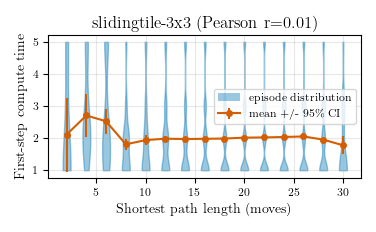

In [9]:
CI95_Z = 1.96  # normal-approximation 95% CI half-width, in units of SEM

# shortest_path_length here is the hardness of initial_puzzle, i.e. at reset -
# so it should be paired with the compute time spent on that first action
# (when the actor is actually looking at initial_puzzle), not the whole
# episode's mean compute_time, which mixes in later steps against a puzzle
# that's since moved past initial_puzzle. compute_times[0] is always valid -
# every episode takes at least one step.
plot_df = df.dropna(subset=["shortest_path_length"]).assign(
    first_step_compute_time=lambda d: d["compute_times"].apply(lambda ct: ct[0])
)

pearson_r = plot_df["shortest_path_length"].corr(plot_df["first_step_compute_time"], method="pearson")
spearman_r = plot_df["shortest_path_length"].corr(plot_df["first_step_compute_time"], method="spearman")
print(f"Pearson r  = {pearson_r:.3f}")
print(f"Spearman r = {spearman_r:.3f}")

by_distance = plot_df.groupby("shortest_path_length")["first_step_compute_time"].agg(["mean", "sem", "count"])

# One violin per shortest-path-length value, positioned at its actual value on
# the x-axis so it lines up with the mean +/- 95% CI overlay below. A KDE-based
# violin needs >= 2 distinct values, so groups that don't qualify (typically
# the sparsely-populated tails) fall back to being represented by that overlay
# alone.
violin_groups = [
    (distance, group["first_step_compute_time"].to_numpy())
    for distance, group in plot_df.groupby("shortest_path_length")
]
violin_groups = [(d, v) for d, v in violin_groups if len(v) >= 2 and np.std(v) > 0]
violin_color = sns.color_palette("colorblind")[0]
mean_color = sns.color_palette("colorblind")[3]

fig, ax = plt.subplots(figsize=set_size(doc_width_pt, fraction=0.6))
if violin_groups:
    parts = ax.violinplot(
        [v for _, v in violin_groups],
        positions=[d for d, _ in violin_groups],
        widths=0.8,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    for body in parts["bodies"]:
        body.set_facecolor(violin_color)
        body.set_edgecolor(violin_color)
        body.set_alpha(0.4)

mean_errorbar = ax.errorbar(
    by_distance.index,
    by_distance["mean"],
    yerr=CI95_Z * by_distance["sem"].fillna(0.0),
    marker="o",
    ms=4,
    linewidth=1.5,
    color=mean_color,
    label=r"mean +/- 95\% CI",
)
ax.legend(
    handles=[Patch(facecolor=violin_color, alpha=0.4, label="episode distribution"), mean_errorbar]
)
ax.set_xlabel("Shortest path length (moves)")
ax.set_ylabel("First-step compute time")
ax.set_title(
    f"slidingtile-{GRID_SIZE}x{GRID_SIZE} "
    f"(Pearson r={pearson_r:.2f})"
)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig(
    "analysis-compute_time-hardness-slidingpuzzle.pdf", dpi=600, format="pdf", bbox_inches="tight"
)


Pearson r  = 0.318
Spearman r = 0.360


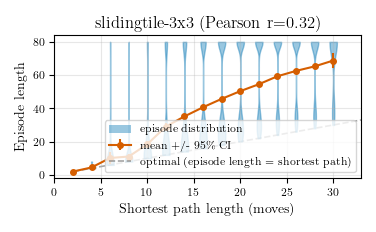

In [10]:
CI95_Z = 1.96  # normal-approximation 95% CI half-width, in units of SEM

plot_df = df.dropna(subset=["shortest_path_length"])

pearson_r = plot_df["shortest_path_length"].corr(plot_df["episode_length"], method="pearson")
spearman_r = plot_df["shortest_path_length"].corr(plot_df["episode_length"], method="spearman")
print(f"Pearson r  = {pearson_r:.3f}")
print(f"Spearman r = {spearman_r:.3f}")

by_distance = plot_df.groupby("shortest_path_length")["episode_length"].agg(["mean", "sem", "count"])

# One violin per shortest-path-length value - see the previous cell for the
# positioning/fallback rationale.
violin_groups = [
    (distance, group["episode_length"].to_numpy())
    for distance, group in plot_df.groupby("shortest_path_length")
]
violin_groups = [(d, v) for d, v in violin_groups if len(v) >= 2 and np.std(v) > 0]
violin_color = sns.color_palette("colorblind")[0]
mean_color = sns.color_palette("colorblind")[3]

fig, ax = plt.subplots(figsize=set_size(doc_width_pt, fraction=0.6))

# Diagonal reference line: episode_length == shortest_path_length is the
# optimal-solving case (no wasted moves) - points/violins above it took more
# steps than necessary. Drawn from the data's own min/max (not (0, 0)) so it
# stays tight to the plotted range; zorder=0 keeps it behind the violins/marker.
axis_min = min(plot_df["shortest_path_length"].min(), plot_df["episode_length"].min())
axis_max = max(plot_df["shortest_path_length"].max(), plot_df["episode_length"].max())
(diagonal_line,) = ax.plot(
    [axis_min, axis_max],
    [axis_min, axis_max],
    linestyle="--",
    color="gray",
    linewidth=1.2,
    alpha=0.7,
    zorder=0,
    label="optimal (episode length = shortest path)",
)

if violin_groups:
    parts = ax.violinplot(
        [v for _, v in violin_groups],
        positions=[d for d, _ in violin_groups],
        widths=0.8,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    for body in parts["bodies"]:
        body.set_facecolor(violin_color)
        body.set_edgecolor(violin_color)
        body.set_alpha(0.4)

mean_errorbar = ax.errorbar(
    by_distance.index,
    by_distance["mean"],
    yerr=CI95_Z * by_distance["sem"].fillna(0.0),
    marker="o",
    ms=4,
    linewidth=1.5,
    color=mean_color,
    label=r"mean +/- 95\% CI",
)
ax.legend(
    handles=[
        Patch(facecolor=violin_color, alpha=0.4, label="episode distribution"),
        mean_errorbar,
        diagonal_line,
    ]
)
ax.set_xlim(0, 33)
ax.set_xlabel("Shortest path length (moves)")
ax.set_ylabel("Episode length")
ax.set_title(f"slidingtile-{GRID_SIZE}x{GRID_SIZE} (Pearson r={pearson_r:.2f})")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig(
    "analysis-episode_length-hardness-slidingpuzzle.pdf", dpi=600, format="pdf", bbox_inches="tight"
)

## Per-step compute time vs. remaining hardness

The two analyses above only look at each episode's *starting* hardness
(shortest path from the puzzle at reset to the solved arrangement).
`rollout_episodes` also records every step's own puzzle (`states`) and the
actor's compute time *at that step* (`compute_times`), padded to
`ROLLOUT_MAX_STEPS` with a `valid_steps` mask marking which entries are real
(episodes that solve before truncating leave trailing padding). This section
drops the padding, recomputes the BFS shortest path from each step's *current*
puzzle to the solved arrangement, and checks whether compute time tracks the
puzzle's remaining difficulty as it's solved, rather than only its difficulty
at reset.

[per-step] Pearson r  = -0.213
[per-step] Spearman r = -0.208


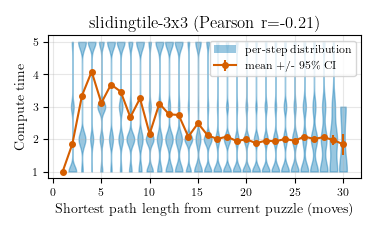

In [11]:
def build_step_dataframe(df, prepared):
    """Expands each episode's padded-to-ROLLOUT_MAX_STEPS `states`/
    `compute_times` (see rollout_episodes) into one row per real step -
    dropping the trailing padding via `valid_steps` - and computes the
    shortest-path length from that step's *current* puzzle to the (fixed)
    solved arrangement."""
    rows = []
    for _, episode_row in df.iterrows():
        if not episode_row["solved"]:
            continue

        for step, (puzzle, action, compute_time, valid) in enumerate(
            zip(
                episode_row["states"],
                episode_row["actions"],
                episode_row["compute_times"],
                episode_row["valid_steps"],
            )
        ):
            if not valid:
                continue

            if sliding_puzzle_shortest_path(prepared, puzzle) == 0:
                continue

            rows.append(
                {
                    "episode": episode_row["episode"],
                    "step": step,
                    "action": int(action),
                    "compute_time": float(compute_time),
                    "shortest_path_length": sliding_puzzle_shortest_path(prepared, puzzle),
                }
            )
    return pd.DataFrame.from_records(rows)


step_df = build_step_dataframe(df, puzzle_dist_prepared)
step_plot_df = step_df.dropna(subset=["shortest_path_length"])

step_pearson_r = step_plot_df["shortest_path_length"].corr(step_plot_df["compute_time"], method="pearson")
step_spearman_r = step_plot_df["shortest_path_length"].corr(step_plot_df["compute_time"], method="spearman")
print(f"[per-step] Pearson r  = {step_pearson_r:.3f}")
print(f"[per-step] Spearman r = {step_spearman_r:.3f}")

by_distance = step_plot_df.groupby("shortest_path_length")["compute_time"].agg(["mean", "sem", "count"])

# One violin per shortest-path-length value - see the episode-level plots
# above for the positioning/fallback rationale.
violin_groups = [
    (distance, group["compute_time"].to_numpy())
    for distance, group in step_plot_df.groupby("shortest_path_length")
]
violin_groups = [(d, v) for d, v in violin_groups if len(v) >= 2 and np.std(v) > 0]
violin_color = sns.color_palette("colorblind")[0]
mean_color = sns.color_palette("colorblind")[3]

fig, ax = plt.subplots(figsize=set_size(doc_width_pt, fraction=0.6))
if violin_groups:
    parts = ax.violinplot(
        [v for _, v in violin_groups],
        positions=[d for d, _ in violin_groups],
        widths=0.8,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    for body in parts["bodies"]:
        body.set_facecolor(violin_color)
        body.set_edgecolor(violin_color)
        body.set_alpha(0.4)

mean_errorbar = ax.errorbar(
    by_distance.index,
    by_distance["mean"],
    yerr=CI95_Z * by_distance["sem"].fillna(0.0),
    marker="o",
    ms=4,
    linewidth=1.5,
    color=mean_color,
    label=r"mean +/- 95\% CI",
)
ax.legend(
    handles=[Patch(facecolor=violin_color, alpha=0.4, label="per-step distribution"), mean_errorbar]
)
ax.set_xlabel("Shortest path length from current puzzle (moves)")
ax.set_ylabel("Compute time")
ax.set_title(
    f"slidingtile-{GRID_SIZE}x{GRID_SIZE} "
    f"(Pearson r={step_pearson_r:.2f})"
)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig(
    "analysis-compute_time-hardness-slidingpuzzle_per_step.pdf",
    dpi=600,
    format="pdf",
    bbox_inches="tight",
)

In [12]:
df["solved"].mean()

0.5249504990099803

## Compute time vs. chosen action

Does the actor spend more (or less) time pondering depending on *which* move it
ends up making? `action` is a discrete index into `jumanji`'s `MOVES = [UP,
RIGHT, DOWN, LEFT]` (see `rollout_episodes`'s new `actions` field) - it has no
inherent linear order (LEFT isn't "more" than UP, it's just a different
direction), so a linear/rank correlation (Pearson/Spearman, treating the action
index as if it were an ordered number) is only a weak, exploratory signal here.
The statistically appropriate measure for "how much of compute_time's variance
is explained by which action was taken" is a one-way ANOVA across actions (its
effect size, eta-squared, is the categorical-vs-continuous analogue of R²) -
both are reported below, alongside a violin plot of compute_time per action.
Unlike Lights Out's ~20 actions (one per grid cell), there are only 4 possible
moves here, so each action has many more per-step observations behind it.

[action as ordinal - see markdown caveat] Pearson r  = -0.044
[action as ordinal - see markdown caveat] Spearman r = -0.023
One-way ANOVA across actions: F = 10872.543, p = 0, eta^2 = 0.0420


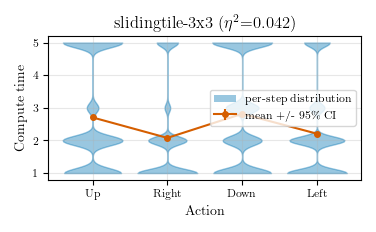

In [13]:
from scipy import stats

ACTION_NAMES = {0: "Up", 1: "Right", 2: "Down", 3: "Left"}  # jumanji's MOVES order

action_pearson_r = step_plot_df["action"].corr(step_plot_df["compute_time"], method="pearson")
action_spearman_r = step_plot_df["action"].corr(step_plot_df["compute_time"], method="spearman")
print(f"[action as ordinal - see markdown caveat] Pearson r  = {action_pearson_r:.3f}")
print(f"[action as ordinal - see markdown caveat] Spearman r = {action_spearman_r:.3f}")

# One-way ANOVA across actions: is compute_time's mean the same regardless of
# which action was taken? eta^2 (SS_between / SS_total) is its effect size -
# the share of compute_time's variance "explained" by the action taken,
# without assuming any order among actions (unlike Pearson/Spearman above).
action_groups = [group["compute_time"].to_numpy() for _, group in step_plot_df.groupby("action")]
f_stat, p_value = stats.f_oneway(*action_groups)
grand_mean = step_plot_df["compute_time"].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in action_groups)
ss_total = ((step_plot_df["compute_time"] - grand_mean) ** 2).sum()
eta_squared = ss_between / ss_total
print(f"One-way ANOVA across actions: F = {f_stat:.3f}, p = {p_value:.3g}, eta^2 = {eta_squared:.4f}")

by_action = step_plot_df.groupby("action")["compute_time"].agg(["mean", "sem", "count"])

# One violin per action - see the shortest-path-length plots above for the
# positioning/fallback rationale (positions are the action indices here
# instead of a hardness value, but otherwise identical).
violin_groups = [
    (action, group["compute_time"].to_numpy()) for action, group in step_plot_df.groupby("action")
]
violin_groups = [(a, v) for a, v in violin_groups if len(v) >= 2 and np.std(v) > 0]
violin_color = sns.color_palette("colorblind")[0]
mean_color = sns.color_palette("colorblind")[3]

fig, ax = plt.subplots(figsize=set_size(doc_width_pt, fraction=0.6))
if violin_groups:
    parts = ax.violinplot(
        [v for _, v in violin_groups],
        positions=[a for a, _ in violin_groups],
        widths=0.8,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    for body in parts["bodies"]:
        body.set_facecolor(violin_color)
        body.set_edgecolor(violin_color)
        body.set_alpha(0.4)

mean_errorbar = ax.errorbar(
    by_action.index,
    by_action["mean"],
    yerr=CI95_Z * by_action["sem"].fillna(0.0),
    marker="o",
    ms=4,
    linewidth=1.5,
    color=mean_color,
    label=r"mean +/- 95\% CI",
)
ax.legend(
    handles=[Patch(facecolor=violin_color, alpha=0.4, label="per-step distribution"), mean_errorbar]
)
ax.set_xticks(list(ACTION_NAMES.keys()), list(ACTION_NAMES.values()))
ax.set_xlabel("Action")
ax.set_ylabel("Compute time")
# eta_squared's `^` needs math mode under text.usetex=True (a bare `^` outside
# `$...$` is invalid LaTeX).
ax.set_title(
    rf"slidingtile-{GRID_SIZE}x{GRID_SIZE} ($\eta^2$={eta_squared:.3f})"
)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig(
    "analysis-compute_time-by_action-slidingpuzzle.pdf", dpi=600, format="pdf", bbox_inches="tight"
)

## t-SNE of visited puzzle states' latent representation, coloured by compute time

Projects the actor's own latent representation of each puzzle - not the raw
puzzle itself - down to 3D with t-SNE, and colours each point by the actor's
compute time there, for both the episode-level view (`initial_puzzle`, one
point per episode - matching the hardness-vs-compute-time plots above) and the
per-step view (one visited puzzle per step, sampled across episodes - matching
the per-step plot above).

`TSNE_LATENT_SOURCE` picks which latent representation to embed:

  - `"initial_token"` (default): the Chain-of-Thought transformer torso's own
    `initial_token` (see `stoix.networks.torso_compute_transformer.
    TransformerChainOfThoughtTorso`) - the CNN `input_layer`'s output (see
    `build_actor_and_restore` and `network=cnn_transformer_compute`'s
    `input_layer`) projected by the torso's own trained `Dense(hidden_dim)`
    (+ `RMSNorm`, since `USE_INPUT_LAYER_NORM`) into the actual first
    "thought" token the CoT loop starts reasoning from - one learned step
    further than the CNN embedding alone. `embed_puzzles` runs this via the
    input_layer's own `apply(method=...)`, then Flax's `nn.Dense`/`nn.RMSNorm`
    loaded with the torso's own trained `Dense_0`/`RMSNorm_0` params - the
    same forward pass the real torso uses, without needing to run its full
    (RNG-requiring) CoT loop just to read off this first token.
  - `"final_state"`: the *last* "thought" instead of the first - the hidden
    state the torso's halting head actually read off at the step each
    trajectory halted at (`_CoTStep`'s `halting_input`/`final_state` in
    `stoix.networks.torso_compute_transformer.py`), i.e. exactly what feeds
    the halting decision (and, identically, the action head) once the actor
    is done thinking, rather than what it started from. Unlike
    `initial_token`, this needs the actor's actual number of CoT steps for
    each puzzle, so `embed_puzzles_final_state` replays the real torso
    (`module.torso(x, target_compute_time=...)`) deterministically for
    exactly `compute_time` steps - the same replay mechanism training's
    REINFORCE loss uses (see `TransformerChainOfThoughtTorso`'s docstring) -
    rather than hand-deriving it, since the CoT loop is not just one more
    `Dense`/`RMSNorm` layer like `initial_token` is.

Both are subsampled to `TSNE_SAMPLE_SIZE` points (t-SNE doesn't scale to tens
of thousands of points) and coloured with a perceptually-uniform sequential
colormap (`viridis`, not a rainbow), since compute_time is continuous.


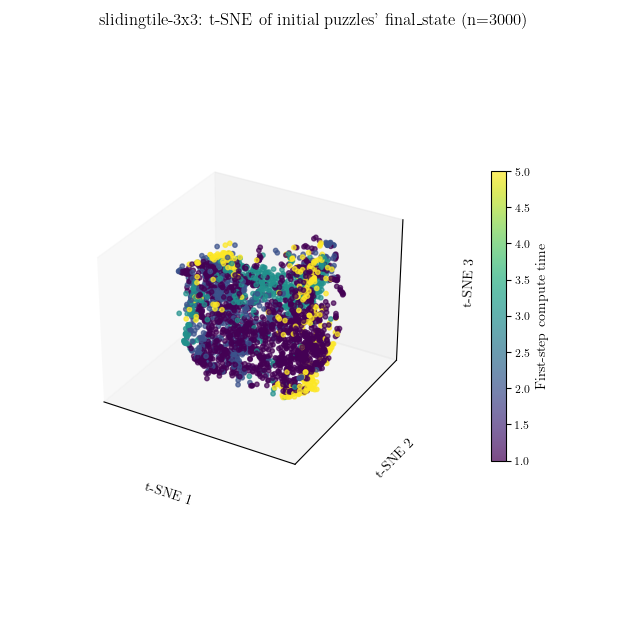

In [18]:
from sklearn.manifold import TSNE

TSNE_SAMPLE_SIZE = 3000  # t-SNE doesn't scale to all NUM_EVAL_EPISODES - subsample instead.
PERPLEXITY = TSNE_SAMPLE_SIZE * 0.05
TSNE_LATENT_SOURCE = "final_state"  # "initial_token" or "final_state" - see markdown above.

def embed_puzzles(actor_params, puzzles):
    """Runs the trained actor's CNN input_layer (see build_actor_and_restore)
    on a batch of (grid_size, grid_size) puzzles, then the torso's own
    initial_token projection (stoix.networks.torso_compute_transformer.
    TransformerChainOfThoughtTorso: a learned Dense(HIDDEN_DIM), plus RMSNorm/
    LayerNorm if USE_INPUT_LAYER_NORM, of the input_layer's output) - the
    actual first "thought" token the Chain-of-Thought loop starts reasoning
    from, one learned step further into the network than input_layer's
    output alone. `method=` calls just the input_layer submodule (skipping
    the full torso, which needs an RNG key for its halting mechanism);
    initial_token's Dense_0/RMSNorm_0 are then applied directly via fresh
    nn.Dense/nn.RMSNorm modules loaded with the torso's own trained params -
    Flax's own forward pass, so numerically identical to the real torso's
    computation, without running its full CoT loop just to read off this
    first token."""
    obs = jnp.asarray(np.stack(puzzles), dtype=jnp.float32)[..., None]  # (n, N, N, 1)
    input_embedding = actor_network.apply(
        actor_params, obs, method=lambda module, x: module.input_layer(x)
    )
    torso_params = actor_params["params"]["torso"]
    initial_token = nn.Dense(HIDDEN_DIM).apply(
        {"params": torso_params["Dense_0"]}, input_embedding
    )
    if USE_INPUT_LAYER_NORM:
        norm_cls = nn.RMSNorm if USE_RMSNORM else nn.LayerNorm
        norm_key = "RMSNorm_0" if USE_RMSNORM else "LayerNorm_0"
        initial_token = norm_cls().apply({"params": torso_params[norm_key]}, initial_token)
    return np.asarray(initial_token)


def embed_puzzles_final_state(actor_params, puzzles, compute_times):
    """Like embed_puzzles, but returns the torso's *final* state instead of
    its initial_token: the "thought" the halting head actually read off at
    the step each puzzle's trajectory halted at (see _CoTStep's
    halting_input/final_state in stoix.networks.torso_compute_transformer.py)
    - the same embedding the action head itself acts on, once the actor is
    done thinking. This can't be hand-derived the way initial_token is (a
    single Dense/RMSNorm layer) - it's the output of `compute_time` weight-
    tied CoT steps - so this instead replays the real torso via
    target_compute_time, deterministically re-running exactly `compute_times`
    steps per puzzle (the same replay mechanism training's REINFORCE loss
    uses - see TransformerChainOfThoughtTorso), which needs no RNG despite
    running the full halting torso."""
    obs = jnp.asarray(np.stack(puzzles), dtype=jnp.float32)[..., None]  # (n, N, N, 1)
    input_embedding = actor_network.apply(
        actor_params, obs, method=lambda module, x: module.input_layer(x)
    )
    target_compute_time = jnp.asarray(compute_times, dtype=jnp.float32)
    final_state, *_ = actor_network.apply(
        actor_params,
        input_embedding,
        jnp.ones_like(target_compute_time, dtype=jnp.float32) * 2,
        method=lambda module, x, t: module.torso(x, target_compute_time=t),
    )
    return np.asarray(final_state)


def embed_puzzle_latents(actor_params, puzzles, compute_times):
    """Dispatches to embed_puzzles or embed_puzzles_final_state according to
    TSNE_LATENT_SOURCE (see markdown above)."""
    if TSNE_LATENT_SOURCE == "initial_token":
        return embed_puzzles(actor_params, puzzles)
    elif TSNE_LATENT_SOURCE == "final_state":
        return embed_puzzles_final_state(actor_params, puzzles, compute_times)
    else:
        raise ValueError(f"Unknown TSNE_LATENT_SOURCE: {TSNE_LATENT_SOURCE!r}")


episode_sample = df.sample(n=min(TSNE_SAMPLE_SIZE, len(df)), random_state=0)
# First-step compute time, not the episode mean - matches the hardness-vs-
# first-step-compute-time plot above (initial_puzzle is what the actor saw on
# that first action). Also what TSNE_LATENT_SOURCE="final_state" replays to.
episode_compute_time = episode_sample["compute_times"].apply(lambda ct: ct[0]).to_numpy()
episode_latents = embed_puzzle_latents(
    actor_params, episode_sample["initial_puzzle"].to_numpy(), episode_compute_time
)

episode_embedding = TSNE(n_components=3, perplexity=PERPLEXITY, random_state=0, init="pca").fit_transform(
    episode_latents
)

# 3D scatter + colorbar is a notoriously cramped matplotlib combination - a
# square (not golden-ratio), full-doc-width figure, explicit label padding, a
# wide colorbar `pad`, and a figure-level suptitle (not ax.set_title, which
# 3D axes tend to clip against the figure edge) keep the title, z-axis label
# and colorbar from overlapping or clipping. No bbox_inches="tight": it
# mis-crops 3D axes' irregular bounding box.
fig = plt.figure(figsize=set_size(doc_width_pt, fraction=1.0, use_golden_ratio=False))
ax = fig.add_subplot(projection="3d")
scatter = ax.scatter(
    episode_embedding[:, 0],
    episode_embedding[:, 1],
    episode_embedding[:, 2],
    c=episode_compute_time,
    cmap="viridis",
    s=10,
    alpha=0.7,
)
fig.colorbar(scatter, ax=ax, label="First-step compute time", shrink=0.6, pad=0.15)
ax.set_xlabel("t-SNE 1", labelpad=10)
ax.set_ylabel("t-SNE 2", labelpad=10)
ax.set_zlabel("t-SNE 3", labelpad=10)
fig.suptitle(
    f"slidingtile-{GRID_SIZE}x{GRID_SIZE}: t-SNE of initial puzzles' {TSNE_LATENT_SOURCE} "
    f"(n={len(episode_sample)})"
)
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
plt.savefig(
    f"analysis-tsne_initial_puzzle-slidingpuzzle-{TSNE_LATENT_SOURCE}.pdf", dpi=600, format="pdf"
)


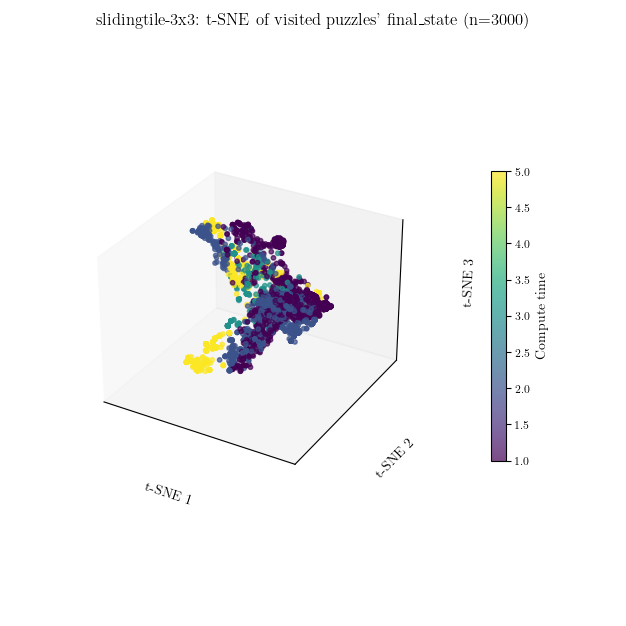

In [19]:
def sample_step_states(df, num_samples, rng):
    """Randomly samples (state, compute_time) pairs, one per sampled episode
    (for diversity across episodes rather than many steps from a few), from
    every episode's valid per-step trajectory (see rollout_episodes) -
    restricted to solved episodes to match build_step_dataframe's convention
    above."""
    solved_df = df[df["solved"]]
    episode_indices = rng.integers(0, len(solved_df), size=num_samples)
    states, compute_times = [], []
    for idx in episode_indices:
        episode_row = solved_df.iloc[idx]
        valid_steps = np.flatnonzero(episode_row["valid_steps"])
        step = rng.choice(valid_steps)
        states.append(episode_row["states"][step])
        compute_times.append(episode_row["compute_times"][step])
    return np.stack(states), np.array(compute_times)


rng = np.random.default_rng(0)
step_states, step_compute_times = sample_step_states(df, TSNE_SAMPLE_SIZE, rng)
step_latents = embed_puzzle_latents(actor_params, step_states, step_compute_times)

step_embedding = TSNE(n_components=3, perplexity=PERPLEXITY, random_state=0, init="pca").fit_transform(
    step_latents
)

# See the previous cell for the 3D-layout rationale (square, full-width
# figure, explicit label padding, wide colorbar pad, figure-level suptitle,
# no bbox_inches="tight").
fig = plt.figure(figsize=set_size(doc_width_pt, fraction=1.0, use_golden_ratio=False))
ax = fig.add_subplot(projection="3d")
scatter = ax.scatter(
    step_embedding[:, 0],
    step_embedding[:, 1],
    step_embedding[:, 2],
    c=step_compute_times,
    cmap="viridis",
    s=10,
    alpha=0.7,
)
fig.colorbar(scatter, ax=ax, label="Compute time", shrink=0.6, pad=0.15)
ax.set_xlabel("t-SNE 1", labelpad=10)
ax.set_ylabel("t-SNE 2", labelpad=10)
ax.set_zlabel("t-SNE 3", labelpad=10)
fig.suptitle(
    f"slidingtile-{GRID_SIZE}x{GRID_SIZE}: t-SNE of visited puzzles' {TSNE_LATENT_SOURCE} "
    f"(n={len(step_states)})"
)
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
plt.savefig(
    f"analysis-tsne_visited_puzzles-slidingpuzzle-{TSNE_LATENT_SOURCE}.pdf", dpi=600, format="pdf"
)


## Export plot data for the standalone plotting scripts

Saves everything `make_hardness_grid_plot.py` and `make_tsne_step_grid_plot.py`
need (see `ramdp_experiments/`) into a single pickle, so those scripts only
need numpy/pandas/sklearn/matplotlib - no JAX/Flax/hydra/checkpoint restore -
to reproduce the combined-figure plots from this notebook and its Lights Out
counterpart side by side.

`embed_puzzles_states_history` returns the torso's *entire* per-step "thought"
trajectory (`states_history`, shape `(n, MAX_STEPS, hidden_dim)`) for the same
`episode_sample` used by the t-SNE cells above - the state after every CoT
step 1..MAX_STEPS, not just `initial_token`/`final_state`. This is exactly
`_CoTStep`'s `state` collected across the whole `nn.scan` (see
`TransformerChainOfThoughtTorso`'s docstring for `states_history`), which is
computed unconditionally at every step regardless of `still_running` -
`target_compute_time` only gates `final_state`/`halting_log_prob`, not
`states_history` itself - so a dummy `target_compute_time` (here, `MAX_STEPS`
for every example) is enough; no per-example replay target is needed for
this.


In [ ]:
import pickle


def embed_puzzles_states_history(actor_params, puzzles):
    """Like embed_puzzles/embed_puzzles_final_state, but returns the torso's
    entire per-step state trajectory (states_history) instead of a single
    embedding - the "thought" after every CoT step 1..MAX_STEPS, for a batch
    of puzzles. See markdown above for why a dummy target_compute_time is
    sufficient here."""
    obs = jnp.asarray(np.stack(puzzles), dtype=jnp.float32)[..., None]  # (n, N, N, 1)
    input_embedding = actor_network.apply(
        actor_params, obs, method=lambda module, x: module.input_layer(x)
    )
    dummy_target_compute_time = jnp.full((len(puzzles),), float(MAX_STEPS))
    _, _, states_history, _, _ = actor_network.apply(
        actor_params,
        input_embedding,
        dummy_target_compute_time,
        method=lambda module, x, t: module.torso(x, target_compute_time=t),
    )
    return np.asarray(states_history)  # (n, MAX_STEPS, hidden_dim)


# --- Data for make_hardness_grid_plot.py (compute time / episode length vs
# hardness) - the full rollout, not the t-SNE subsample, matching the
# hardness-vs-compute-time and hardness-vs-episode-length cells above.
plot_df_summary = df.dropna(subset=["shortest_path_length"]).assign(
    first_step_compute_time=lambda d: d["compute_times"].apply(lambda ct: ct[0])
)

# --- Data for make_tsne_step_grid_plot.py (per-CoT-step latent t-SNE) - the
# same episode_sample/episode_compute_time as the t-SNE cells above, plus its
# full per-step state trajectory.
step_latents_history = embed_puzzles_states_history(
    actor_params, episode_sample["initial_puzzle"].to_numpy()
)

plot_data = {
    "env_label": f"slidingtile-{GRID_SIZE}x{GRID_SIZE}",
    "max_steps": MAX_STEPS,
    "hardness": plot_df_summary["shortest_path_length"].to_numpy(),
    "first_step_compute_time": plot_df_summary["first_step_compute_time"].to_numpy(),
    "episode_length": plot_df_summary["episode_length"].to_numpy(),
    "tsne_sample_hardness": episode_sample["shortest_path_length"].to_numpy(),
    "tsne_sample_compute_time": episode_compute_time,
    "step_latents": step_latents_history,
}

PLOT_DATA_PATH = REPO_ROOT / "ramdp_experiments" / "plot_data-slidingpuzzle.pkl"
with open(PLOT_DATA_PATH, "wb") as f:
    pickle.dump(plot_data, f)
print(f"Saved plot data to {PLOT_DATA_PATH}")
